# Caregiver response screening and payment review

## Summary

Run this notebook from top to bottom to refresh four REDCap studies, verify their identities,
screen eligible records, and create **ESD_AllResponses_AllStudies_2026-09-24.xlsx**.
The executed summary below reports the current counts; no historical record totals are assumed.

Study names and PIDs stay together throughout the analysis. A record is identified by
**PID + Record ID**, never by Record ID alone.

> Screening rules identify responses that may need additional review. A triggered rule does not,
> by itself, prove that a response was submitted by a bot. Payment labels are screening
> recommendations; this notebook does not send payments.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

# Supports execution from the repository root or this notebook's folder.
candidates = [Path.cwd(), Path.cwd() / "projects/caregiver-cluster-analysis"]
project_dir = next((p for p in candidates if (p / "refined_sources.py").exists()), None)
if project_dir is None:
    raise RuntimeError("Run from the repository root or projects/caregiver-cluster-analysis.")
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from generate_all_responses_excel import run_refined_export
import refined_screening as screening

REFRESH_FROM_REDCAP = True  # False explicitly reuses a verified snapshot, without API fallback.
OUTPUT_PATH = project_dir / "Caregiver Outputs/restricted/ESD_AllResponses_AllStudies_2026-09-24.xlsx"
pd.set_option("display.max_colwidth", 85)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

result = run_refined_export(project_dir, refresh=REFRESH_FROM_REDCAP, output_path=OUTPUT_PATH)
sources = result["sources"]
scored = result["scored"]
summary = result["summary"]
display(summary)
display(Markdown(f"**Screened:** {len(scored):,} records. **Excluded:** {len(sources.exclusions):,} records. "
                 "The workbook includes the exclusions and their reasons separately."))

,Study,PID,Analyzed records,Pay now,Check by hand,Do not pay,Incomplete - not eligible,Excluded records,Source records,Mapping review records
0,Study 1 - Infant Autism Screening [CAN Registry] (PID 4797),4797,113,58,9,0,46,64,177,0
1,Study 2 - old-Infant Autism Screening [Global] (PID 4581),4581,1518,419,890,11,198,261,1779,0
2,Study 3 - Infant Autism Screening-27Sep25_bilingual-13Jul26 [Prisma List] (PID 5749),5749,41,13,6,0,22,481,522,3
3,Study 4 - Infant Autism Screening - ICIS [ICIS Board] (PID 4931),4931,6,3,1,0,2,4,10,0
4,All studies,All,1678,493,906,11,268,810,2488,3


**Screened:** 1,678 records. **Excluded:** 810 records. The workbook includes the exclusions and their reasons separately.

## Context and methods

The study team needs a concise payment list while retaining evidence for each decision.
The supplied implementation prompt is a proposed specification. The live REDCap metadata and
the study-reference CSV govern field meanings and project identity.

### Assumptions that affect the result

- The four active studies are PIDs **4797, 4581, 5749, and 4931**. Each token is checked against
  REDCap's project-information endpoint before its records are accepted.
- PID 5749 records **1–445** are copied archive records and excluded from this prospective cohort.
  Records **446–473** retain the existing pre-launch exclusion. PID 4700 is not merged into PID 5749.
- Every source text/notes field is searched for the case-insensitive whole word **test**, before
  language folding. This requested rule also excludes natural phrases such as “autism test.”
  Exclusions remain auditable and do not count as detected bots.
- Spanish choice fields are folded using live choice meanings and language selection. Missing,
  unavailable, and conflicting answers stay distinct from passing answers.
- Risk points retain all 15 requested signals. Final payment decisions also consider independent
  evidence, survey completion, contact details, and unresolved source issues. The score-only
  proposal is retained for comparison rather than treated as proven bot classification.
- Pronoun/gender pairings are contextual. Disability/autism answers can need clarification.
  Neither establishes bot activity. University email domains do not prove identity.
- Times are REDCap project-local survey times. Timing thresholds are screening assumptions,
  not estimates of a respondent's probability of being a bot.

## Data

### Verified studies and source reconciliation

The table records each live PID/title check, extraction time, and counts. Any project-identity
mismatch or failed source fetch stops the export rather than silently producing a partial workbook.

In [2]:
display(sources.provenance[["project_id", "study_name", "source_mode", "fetched_at_utc",
                            "raw_records", "excluded_records", "included_records",
                            "source_mapping_review_records"]])
reconciliation = pd.DataFrame([
    {"Study": item["display_label"], "REDCap PID": pid,
     "Screened records": len(sources.records_by_pid[pid])}
    for pid, item in sources.registry.items()
])
assert reconciliation["Screened records"].sum() == len(scored)
assert scored[["REDCap PID", "Record ID"]].astype(str).duplicated().sum() == 0
display(reconciliation)

,project_id,study_name,source_mode,fetched_at_utc,raw_records,excluded_records,included_records,source_mapping_review_records
0,4797,Infant Autism Screening,Fresh REDCap API export,2026-09-25T02:04:44.077342+00:00,177,64,113,0
1,4581,old-Infant Autism Screening,Fresh REDCap API export,2026-09-25T02:04:44.077342+00:00,1779,261,1518,0
2,5749,Infant Autism Screening-27Sep25_bilingual-13Jul26,Fresh REDCap API export,2026-09-25T02:04:44.077342+00:00,522,481,41,3
3,4931,Infant Autism Screening - ICIS,Fresh REDCap API export,2026-09-25T02:04:44.077342+00:00,10,4,6,0


,Study,REDCap PID,Screened records
0,Study 1 - Infant Autism Screening [CAN Registry] (PID 4797),4797,113
1,Study 2 - old-Infant Autism Screening [Global] (PID 4581),4581,1518
2,Study 3 - Infant Autism Screening-27Sep25_bilingual-13Jul26 [Prisma List] (PID 5749),5749,41
3,Study 4 - Infant Autism Screening - ICIS [ICIS Board] (PID 4931),4931,6


### Exclusions and language mappings

Exclusions are not payment refusals. The restricted workbook keeps their record keys and reasons.
The notebook displays counts and metadata only, so contact details stay in the restricted output.

In [3]:
if not sources.exclusions.empty:
    group_columns = [c for c in sources.exclusions.columns
                     if c.lower() in {"redcap pid", "pid", "project_id", "reason", "exclusion reason", "exclusion_reason"}]
    if group_columns:
        display(sources.exclusions.groupby(group_columns, dropna=False).size().reset_index(name="Records"))
    else:
        display(pd.DataFrame({"Excluded records": [len(sources.exclusions)]}))
display(sources.field_mapping.head(12))
if not sources.folding_audit.empty:
    display(Markdown(f"**Language-folding audit:** {len(sources.folding_audit):,} entries retained in the workbook."))

,project_id,exclusion_reason,Records
0,4581,Standalone word 'test' in a text/notes response,261
1,4797,Standalone word 'test' in a text/notes response,64
2,4931,Standalone word 'test' in a text/notes response,4
3,5749,Archived clone from PID 4700 (records 1-445),380
4,5749,Archived clone from PID 4700 (records 1-445); Standalone word 'test' in a text/no...,65
5,5749,Pre-launch internal test protocol (records 446-473),8
6,5749,Pre-launch internal test protocol (records 446-473); Standalone word 'test' in a ...,20
7,5749,Standalone word 'test' in a text/notes response,8


,project_id,source_field,canonical_field,field_type,choice_codes,mapping_status,invalid_response_count,mapping_notes
0,4797,record_id,record_id,text,,Live metadata validated,0,
1,4797,intro,intro,descriptive,,Live metadata validated,0,
2,4797,header_elig,header_elig,descriptive,,Live metadata validated,0,
3,4797,email_elig,email_elig,text,,Live metadata validated,0,
4,4797,age_elig,age_elig,radio,"1, 2",Live metadata validated,0,
5,4797,age_confirm_elig,age_confirm_elig,text,,Live metadata validated,0,
6,4797,occup_1,occup_1,text,,Live metadata validated,0,
7,4797,children_elig,children_elig,radio,"1, 0",Live metadata validated,0,
8,4797,pronouns_elig,pronouns_elig,radio,"1, 2, 3, 4",Live metadata validated,0,
9,4797,elig_pic1,elig_pic1,descriptive,,Live metadata validated,0,


**Language-folding audit:** 195 entries retained in the workbook.

### Screening rule definitions

Each check exposes an observed flag, evaluation status, and supporting evidence. “Not applicable”
is used when a study did not ask the question; “not evaluated” is distinct from a pass.
The rule key explains which signals can support refusal and which require context.

In [4]:
display(screening.rule_catalog())

,Rule,Check,Prompt points,Evidence family,Definition and interpretation
0,R1,Whole survey below configured time floor,2,Timing,All four nonnegative section times recorded; sum < 11.57 minutes. Shares one evid...
1,R2,Thoughts and feelings below configured time floor,2,Timing,Nonnegative Thoughts and Feelings time < 7.85 minutes. Shares one evidence family...
2,R3,A section below its configured time floor,1,Timing,"Recorded FIF <2.55, Values <0.22, TFA <6.67, or Demographics <0.95 minutes. Suppo..."
3,R4,Repeated answers in a rating block,1,Copying,"Within a metadata-defined rating block, >=80% and >=4 items answered, sample SD <..."
4,R5,Identical response pattern,2,Copying,"Exact SHA-256 match on >=20 metadata-defined rating items, >=80% valid answers, w..."
5,R6,At least two other sign-ups within two minutes,2,Context,At least two other records in the same study arrived within +/-120 seconds. Recru...
6,R7,Highly similar substantive written responses,1,Copying,TF-IDF 1-2 gram cosine >0.90 on participant narrative >=100 characters and >=20 w...
7,R8,Family count or branching inconsistency,2,Logic,"Metadata-gated autism follow-ups despite zero autistic children, too many selecte..."
8,R9,Age or postal information needs checking,2,Review,"Reported age outside 18-100, malformed nonempty US ZIP, or parent birth-year inte..."
9,R10,Temporary email domain,1,Context,Email domain on the documented temporary-domain list; requires a usable payment c...


## Results

### Payment recommendations by study

These counts describe the screened cohort after exclusions. Cohorts have different recruitment
sources and sizes; the chart does not estimate bot prevalence or detector accuracy.

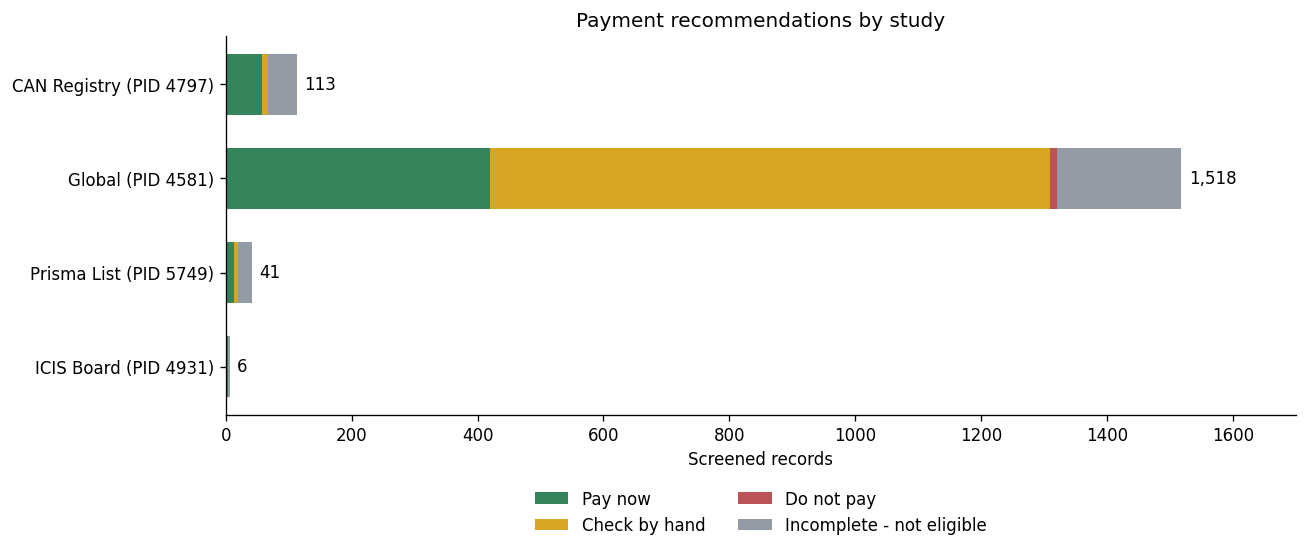

Recommended action,Pay now,Check by hand,Do not pay,Incomplete - not eligible
REDCap PID,,,,
4797,58,9,0,46
4581,419,890,11,198
5749,13,6,0,22
4931,3,1,0,2


In [5]:
action_order = ["Pay now", "Check by hand", "Do not pay", "Incomplete - not eligible"]
action_colors = ["#36845B", "#D8A523", "#B95355", "#949BA5"]
counts = (pd.crosstab(scored["REDCap PID"], scored["Recommended action"])
          .reindex(index=list(sources.registry), columns=action_order, fill_value=0))
labels = [f"{sources.registry[pid]['population']} (PID {pid})" for pid in counts.index]
fig, ax = plt.subplots(figsize=(11, 4.8))
left = pd.Series(0, index=counts.index)
for action, color in zip(action_order, action_colors):
    ax.barh(labels, counts[action], left=left, label=action, color=color, height=0.65)
    left = left + counts[action]
for i, total in enumerate(counts.sum(axis=1)):
    ax.text(total + max(left.max() * 0.008, 1), i, f"{total:,}", va="center")
ax.set_xlim(0, max(left.max() * 1.12, 1))
ax.set_xlabel("Screened records")
ax.set_title("Payment recommendations by study")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
fig.tight_layout()
display(fig)
plt.close(fig)
display(counts.rename_axis("REDCap PID"))

### Reference-cohort check

The study CSV describes CAN Registry and ICIS as confirmed-real reference cohorts.
Their action distribution is an in-sample reasonableness check, not an independent validation set.
Any refusals in these cohorts need attention when assessing the policy's false-positive risk.

In [6]:
reference = scored[scored["REDCap PID"].astype(int).isin([4797, 4931])]
reference_counts = pd.crosstab(reference["REDCap PID"], reference["Recommended action"]).reindex(
    columns=action_order, fill_value=0)
display(reference_counts)
refusals = int(reference["Recommended action"].eq("Do not pay").sum())
display(Markdown(f"**Reference-cohort refusals:** {refusals:,} of {len(reference):,} screened reference responses. "
                 "Cohort provenance does not bypass record-level checks."))

Recommended action,Pay now,Check by hand,Do not pay,Incomplete - not eligible
REDCap PID,,,,
4797,58,9,0,46
4931,3,1,0,2


**Reference-cohort refusals:** 0 of 119 screened reference responses. Cohort provenance does not bypass record-level checks.

### Records needing clarification

Reasons are grouped here to show the remaining review workload. Exact response keys, contact
details, observed answers, and per-rule evidence are available in the restricted workbook.

In [7]:
review = scored[scored["Recommended action"].eq("Check by hand")]
display(review["Why this action"].value_counts().head(12).rename_axis("Review reason").reset_index(name="Records"))
display(Markdown(f"**Manual-review queue:** {len(review):,} records."))

,Review reason,Records
0,Clarify disability wording versus autistic-child count.,421
1,Verify unusually short survey time.,206
2,Verify unusually short survey time; Clarify disability wording versus autistic-ch...,204
3,Verify age or postal information.,24
4,Verify age or postal information; Clarify disability wording versus autistic-chil...,7
5,Clarify family count or stored follow-up answers.,6
6,Verify unusually short survey time; Clarify disability wording versus autistic-ch...,5
7,Review Band-Aid answer or reported image issue.,4
8,Obtain usable payment email.,4
9,Compare matching response pattern or substantive comments.,4


**Manual-review queue:** 906 records.

## Validation and workbook

The export verifies PID/record uniqueness, source/exclusion reconciliation, all 15 rule flags,
weighted scores, and final decisions. The workbook includes Excel formulas that recompute checks
from the exported evidence. A triggered screening rule is an observed concern; a regression
failure means the implementation and its independent check disagree.

In [8]:
display(pd.DataFrame([{"Check": key, "Result": str(value)}
                      for key, value in result["validation"].items()]))
display(Markdown(f"**Workbook:** [{OUTPUT_PATH.name}](Caregiver%20Outputs/restricted/{OUTPUT_PATH.name})"))

,Check,Result
0,records,1678
1,sheets,12
2,formula_checks,57080
3,formula_errors,0
4,score_parity,PASS
5,decision_parity,PASS
6,rule_parity,PASS
7,keys_unique,True
8,authoring_engine,artifact-tool
9,native_calculation_engine,LibreOffice


**Workbook:** [ESD_AllResponses_AllStudies_2026-09-24.xlsx](Caregiver%20Outputs/restricted/ESD_AllResponses_AllStudies_2026-09-24.xlsx)

## Takeaways

Use **Recommended action** and **Why this action** for the payment queue. Use the rule evidence
to resolve “Check by hand” cases. The audit sheets retain excluded records and source lineage.
“Do not pay” expresses the evidence-based screening recommendation, not a confirmed bot identity.

Run this notebook again to refresh sources and regenerate the same requested output. Set
`REFRESH_FROM_REDCAP = False` only when intentionally reproducing a verified cached snapshot.

### Optional record lookup

The lookup requires a PID and a Record ID together. Its default output omits email addresses.
Only request contact fields in a restricted working session.

In [9]:
def find_response(pid, record_id, include_contact=False):
    matches = scored[
        scored["REDCap PID"].astype(str).eq(str(pid))
        & scored["Record ID"].astype(str).eq(str(record_id))
    ].copy()
    if not include_contact:
        matches = matches.drop(columns=[c for c in matches if "email" in c.lower()], errors="ignore")
    return matches

# Example (leave commented to avoid saving record-level output in this notebook):
# display(find_response(5749, "474"))